# Agente inteligente para clasificación binaria optimizada por AUC

Esta versión implementa un agente más completo para Jupyter. El agente coordina todo el proceso desde la carga del dataset hasta la predicción final por AUC.

Incluye:

1. Carga del dataset.
2. Diagnóstico automático.
3. Limpieza inteligente.
4. Detección de variables numéricas y categóricas.
5. Análisis de balance de clases.
6. Preprocesamiento automático.
7. Comparación de varios modelos.
8. Validación cruzada estratificada.
9. Ajuste de hiperparámetros.
10. Selección automática del mejor modelo.
11. Optimización del umbral de clasificación.
12. Evaluación final con AUC.
13. Interpretación automática.
14. Importancia de variables.
15. Predicción con nuevos registros.
16. Guardado del agente completo.

In [14]:
# CELDA 1: Instalación opcional
# !pip install pandas numpy scikit-learn matplotlib joblib

In [15]:
# CELDA 2: Librerías
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42

In [16]:
# CELDA 3: Clase del agente inteligente

class SmartAUCClassificationAgent:
    def __init__(self, target_column, test_size=0.25, random_state=42, cv_splits=5, n_iter_search=20):
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state
        self.cv_splits = cv_splits
        self.n_iter_search = n_iter_search

        self.data = None
        self.X = None
        self.y = None
        self.y_encoder = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.numeric_features = []
        self.categorical_features = []
        self.dropped_columns = []

        self.class_balance = None
        self.imbalance_detected = False

        self.preprocessor = None
        self.models = {}
        self.search_spaces = {}

        self.cv_results = None
        self.tuned_results = None

        self.best_model_name = None
        self.best_model = None
        self.best_auc = None
        self.best_threshold = 0.5

    def load_dataset(self, path):
        print("1. Cargando dataset...")
        self.data = pd.read_csv(path)
        print(f"Dataset cargado: {self.data.shape[0]} filas y {self.data.shape[1]} columnas.")
        return self.data.head()

    def diagnose_dataset(self):
        print("\n2. Diagnóstico inteligente del dataset")
        if self.data is None:
            raise ValueError("Primero debe cargar el dataset.")

        print("\nPrimeras filas:")
        display(self.data.head())
        print("\nDimensiones:", self.data.shape)
        print("\nTipos de datos:")
        display(self.data.dtypes)

        print("\nValores faltantes por columna:")
        missing = self.data.isnull().sum().sort_values(ascending=False)
        display(missing[missing > 0])

        print("\nDuplicados:", self.data.duplicated().sum())

        single_value_cols = [c for c in self.data.columns if self.data[c].nunique(dropna=False) <= 1]
        print("\nColumnas constantes:", single_value_cols if single_value_cols else "Ninguna")

        possible_ids = []
        for c in self.data.columns:
            if c != self.target_column:
                unique_ratio = self.data[c].nunique(dropna=True) / max(len(self.data), 1)
                if unique_ratio > 0.95:
                    possible_ids.append(c)
        print("\nPosibles identificadores:", possible_ids if possible_ids else "Ninguno")

        return {"missing": missing, "single_value_columns": single_value_cols, "possible_id_columns": possible_ids}

    def clean_dataset(self, drop_possible_ids=True):
        print("\n3. Limpieza inteligente del dataset")
        df = self.data.copy()
        before = len(df)
        df = df.drop_duplicates()
        print("Duplicados eliminados:", before - len(df))

        cols_to_drop = []
        for c in df.columns:
            if c != self.target_column and df[c].nunique(dropna=False) <= 1:
                cols_to_drop.append(c)

        if drop_possible_ids:
            for c in df.columns:
                if c != self.target_column:
                    unique_ratio = df[c].nunique(dropna=True) / max(len(df), 1)
                    if unique_ratio > 0.95:
                        cols_to_drop.append(c)

        cols_to_drop = list(set(cols_to_drop))
        self.dropped_columns = cols_to_drop

        if cols_to_drop:
            df = df.drop(columns=cols_to_drop)
            print("Columnas eliminadas automáticamente:", cols_to_drop)
        else:
            print("No se eliminaron columnas.")

        self.data = df
        print("Dataset después de limpieza:", self.data.shape)

    def prepare_target_and_features(self):
        print("\n4. Preparando variable objetivo y predictoras")

        if self.target_column not in self.data.columns:
            raise ValueError(f"La columna objetivo '{self.target_column}' no existe.")

        self.X = self.data.drop(columns=[self.target_column])
        self.y = self.data[self.target_column]

        if self.y.isnull().sum() > 0:
            raise ValueError("La variable objetivo tiene valores faltantes.")

        if self.y.dtype == "object" or str(self.y.dtype).startswith("category") or self.y.dtype == "bool":
            self.y_encoder = LabelEncoder()
            self.y = self.y_encoder.fit_transform(self.y)
            print("Variable objetivo codificada automáticamente.")
            print("Clases originales:", list(self.y_encoder.classes_))

        classes = np.unique(self.y)
        if len(classes) != 2:
            raise ValueError(f"Este agente es para clasificación binaria. Clases detectadas: {classes}")

        self.numeric_features = self.X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
        self.categorical_features = self.X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

        print("Variables numéricas:", self.numeric_features)
        print("Variables categóricas:", self.categorical_features)

    def analyze_class_balance(self):
        print("\n5. Analizando balance de clases")
        counts = pd.Series(self.y).value_counts().sort_index()
        proportions = pd.Series(self.y).value_counts(normalize=True).sort_index()

        balance_df = pd.DataFrame({"clase": counts.index, "frecuencia": counts.values, "proporcion": proportions.values})
        self.class_balance = balance_df
        display(balance_df)

        self.imbalance_detected = proportions.min() < 0.30
        if self.imbalance_detected:
            print("Se detecta desbalance. Se usarán pesos balanceados cuando el modelo lo permita.")
        else:
            print("No se detecta desbalance severo.")

        plt.figure(figsize=(6, 4))
        plt.bar(balance_df["clase"].astype(str), balance_df["frecuencia"])
        plt.title("Distribución de clases")
        plt.xlabel("Clase")
        plt.ylabel("Frecuencia")
        plt.show()

    def split_data(self):
        print("\n6. Dividiendo datos")
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=self.test_size, random_state=self.random_state, stratify=self.y
        )
        print("X_train:", self.X_train.shape)
        print("X_test:", self.X_test.shape)

    def build_preprocessor(self):
        print("\n7. Construyendo preprocesamiento")

        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

        self.preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, self.numeric_features),
                ("cat", categorical_transformer, self.categorical_features)
            ],
            remainder="drop"
        )
        print("Preprocesamiento listo.")

    def define_models_and_search_spaces(self):
        print("\n8. Definiendo modelos candidatos")
        balanced = "balanced" if self.imbalance_detected else None

        self.models = {
            "LogisticRegression": LogisticRegression(max_iter=2000, class_weight=balanced, random_state=self.random_state),
            "DecisionTree": DecisionTreeClassifier(class_weight=balanced, random_state=self.random_state),
            "RandomForest": RandomForestClassifier(class_weight=balanced, random_state=self.random_state),
            "ExtraTrees": ExtraTreesClassifier(class_weight=balanced, random_state=self.random_state),
            "GradientBoosting": GradientBoostingClassifier(random_state=self.random_state),
            "AdaBoost": AdaBoostClassifier(random_state=self.random_state),
            "KNN": KNeighborsClassifier(),
            "SVM": SVC(probability=True, class_weight=balanced, random_state=self.random_state),
            "NaiveBayes": GaussianNB()
        }

        self.search_spaces = {
            "LogisticRegression": {"model__C": np.logspace(-3, 2, 10), "model__solver": ["lbfgs", "liblinear"]},
            "DecisionTree": {"model__max_depth": [None, 3, 5, 8, 12, 20], "model__min_samples_split": [2, 5, 10, 20], "model__min_samples_leaf": [1, 2, 4, 8]},
            "RandomForest": {"model__n_estimators": [100, 200, 300], "model__max_depth": [None, 5, 10, 20], "model__min_samples_split": [2, 5, 10], "model__min_samples_leaf": [1, 2, 4]},
            "ExtraTrees": {"model__n_estimators": [100, 200, 300], "model__max_depth": [None, 5, 10, 20], "model__min_samples_split": [2, 5, 10], "model__min_samples_leaf": [1, 2, 4]},
            "GradientBoosting": {"model__n_estimators": [50, 100, 200], "model__learning_rate": [0.01, 0.05, 0.1, 0.2], "model__max_depth": [2, 3, 5]},
            "AdaBoost": {"model__n_estimators": [50, 100, 200], "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]},
            "KNN": {"model__n_neighbors": [3, 5, 7, 9, 15, 21], "model__weights": ["uniform", "distance"]},
            "SVM": {"model__C": [0.1, 1, 10, 50], "model__gamma": ["scale", "auto"], "model__kernel": ["rbf", "linear"]},
            "NaiveBayes": {"model__var_smoothing": np.logspace(-12, -7, 6)}
        }
        print(f"Modelos definidos: {len(self.models)}")

    def baseline_cross_validation(self):
        print("\n9. Validación cruzada inicial por AUC")
        cv = StratifiedKFold(n_splits=self.cv_splits, shuffle=True, random_state=self.random_state)
        rows = []

        for name, model in self.models.items():
            print(f"Evaluando {name}...")
            pipe = Pipeline(steps=[("preprocessor", self.preprocessor), ("model", model)])
            try:
                scores = cross_val_score(pipe, self.X_train, self.y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
                rows.append({"modelo": name, "auc_cv_promedio": scores.mean(), "auc_cv_std": scores.std()})
            except Exception as e:
                print(f"Error en {name}: {e}")

        self.cv_results = pd.DataFrame(rows).sort_values(by="auc_cv_promedio", ascending=False).reset_index(drop=True)
        display(self.cv_results)
        return self.cv_results

    def tune_top_models(self, top_n=4):
        print("\n10. Ajuste inteligente de hiperparámetros")
        top_models = self.cv_results.head(top_n)["modelo"].tolist()
        print("Modelos seleccionados para ajuste:", top_models)

        cv = StratifiedKFold(n_splits=self.cv_splits, shuffle=True, random_state=self.random_state)
        rows = []
        best_estimators = {}

        for name in top_models:
            print(f"Optimizando {name}...")
            pipe = Pipeline(steps=[("preprocessor", self.preprocessor), ("model", self.models[name])])
            search = RandomizedSearchCV(
                estimator=pipe,
                param_distributions=self.search_spaces[name],
                n_iter=self.n_iter_search,
                scoring="roc_auc",
                cv=cv,
                n_jobs=-1,
                random_state=self.random_state,
                verbose=0
            )
            try:
                search.fit(self.X_train, self.y_train)
                rows.append({"modelo": name, "mejor_auc_cv": search.best_score_, "mejores_parametros": search.best_params_})
                best_estimators[name] = search.best_estimator_
            except Exception as e:
                print(f"Error optimizando {name}: {e}")

        self.tuned_results = pd.DataFrame(rows).sort_values(by="mejor_auc_cv", ascending=False).reset_index(drop=True)
        display(self.tuned_results)

        self.best_model_name = self.tuned_results.loc[0, "modelo"]
        self.best_auc = self.tuned_results.loc[0, "mejor_auc_cv"]
        self.best_model = best_estimators[self.best_model_name]

        print("Mejor modelo:", self.best_model_name)
        print("AUC promedio CV:", round(self.best_auc, 4))
        return self.tuned_results

    def optimize_threshold(self):
        print("\n11. Optimizando umbral de clasificación")
        y_proba = self.best_model.predict_proba(self.X_test)[:, 1]
        thresholds = np.arange(0.05, 0.96, 0.01)
        rows = []

        for threshold in thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            rows.append({
                "threshold": threshold,
                "accuracy": accuracy_score(self.y_test, y_pred),
                "precision": precision_score(self.y_test, y_pred, zero_division=0),
                "recall": recall_score(self.y_test, y_pred, zero_division=0),
                "f1": f1_score(self.y_test, y_pred, zero_division=0)
            })

        threshold_df = pd.DataFrame(rows)
        best_row = threshold_df.sort_values(by="f1", ascending=False).iloc[0]
        self.best_threshold = float(best_row["threshold"])

        print("Mejor umbral según F1:", round(self.best_threshold, 2))
        display(threshold_df.sort_values(by="f1", ascending=False).head(10))

        plt.figure(figsize=(8, 5))
        plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
        plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
        plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
        plt.xlabel("Umbral")
        plt.ylabel("Métrica")
        plt.title("Optimización del umbral")
        plt.legend()
        plt.show()
        return threshold_df

    def final_evaluation(self):
        print("\n12. Evaluación final")
        y_proba = self.best_model.predict_proba(self.X_test)[:, 1]
        y_pred_050 = (y_proba >= 0.5).astype(int)
        y_pred_opt = (y_proba >= self.best_threshold).astype(int)
        auc = roc_auc_score(self.y_test, y_proba)

        print("Modelo final:", self.best_model_name)
        print("AUC test:", round(auc, 4))
        print("Umbral optimizado:", round(self.best_threshold, 2))

        report = pd.DataFrame([
            {"escenario": "umbral_0.50", "auc": auc, "accuracy": accuracy_score(self.y_test, y_pred_050), "precision": precision_score(self.y_test, y_pred_050, zero_division=0), "recall": recall_score(self.y_test, y_pred_050, zero_division=0), "f1": f1_score(self.y_test, y_pred_050, zero_division=0)},
            {"escenario": "umbral_optimizado", "auc": auc, "accuracy": accuracy_score(self.y_test, y_pred_opt), "precision": precision_score(self.y_test, y_pred_opt, zero_division=0), "recall": recall_score(self.y_test, y_pred_opt, zero_division=0), "f1": f1_score(self.y_test, y_pred_opt, zero_division=0)}
        ])
        display(report)

        print("\nMatriz de confusión con umbral optimizado:")
        print(confusion_matrix(self.y_test, y_pred_opt))
        print("\nReporte de clasificación:")
        print(classification_report(self.y_test, y_pred_opt))

        RocCurveDisplay.from_predictions(self.y_test, y_proba)
        plt.title(f"Curva ROC - {self.best_model_name}")
        plt.show()

        self.interpret_auc(auc)
        return report

    def interpret_auc(self, auc):
        print("\nInterpretación automática del AUC:")
        if auc < 0.60:
            print("Bajo poder discriminativo. Revise variables, calidad de datos o ingeniería de características.")
        elif auc < 0.70:
            print("Desempeño moderado-bajo. Sirve como línea base, pero requiere mejora.")
        elif auc < 0.80:
            print("Desempeño aceptable. El modelo discrimina razonablemente entre clases.")
        elif auc < 0.90:
            print("Buen desempeño predictivo.")
        else:
            print("Desempeño muy alto. Revise posible fuga de información si parece demasiado bueno.")

    def explain_model_with_permutation_importance(self, n_repeats=5, top_n=15):
        print("\n13. Importancia de variables")
        try:
            result = permutation_importance(
                self.best_model, self.X_test, self.y_test,
                scoring="roc_auc", n_repeats=n_repeats,
                random_state=self.random_state, n_jobs=-1
            )
            importance_df = pd.DataFrame({
                "variable": self.X_test.columns,
                "importancia_media": result.importances_mean,
                "importancia_std": result.importances_std
            }).sort_values(by="importancia_media", ascending=False)
            display(importance_df.head(top_n))

            plot_df = importance_df.head(top_n).sort_values("importancia_media")
            plt.figure(figsize=(9, 6))
            plt.barh(plot_df["variable"], plot_df["importancia_media"])
            plt.xlabel("Disminución promedio del AUC")
            plt.title("Variables más importantes")
            plt.show()
            return importance_df
        except Exception as e:
            print("No fue posible calcular importancia de variables:", e)
            return None

    def predict_new_data(self, new_data, threshold=None):
        print("\n14. Predicción sobre nuevos datos")
        if threshold is None:
            threshold = self.best_threshold
        if isinstance(new_data, dict):
            new_data = pd.DataFrame([new_data])
        for col in self.dropped_columns:
            if col in new_data.columns:
                new_data = new_data.drop(columns=[col])
        expected_cols = list(self.X.columns)
        missing_cols = [c for c in expected_cols if c not in new_data.columns]
        if missing_cols:
            raise ValueError(f"Faltan columnas: {missing_cols}")
        new_data = new_data[expected_cols]
        proba = self.best_model.predict_proba(new_data)[:, 1]
        pred = (proba >= threshold).astype(int)
        output = pd.DataFrame({"probabilidad_clase_positiva": proba, "umbral_usado": threshold, "prediccion_codificada": pred})
        if self.y_encoder is not None:
            output["prediccion_original"] = self.y_encoder.inverse_transform(pred)
        return output

    def save_agent(self, filename="smart_auc_agent.pkl"):
        joblib.dump(self, filename)
        print(f"Agente guardado como: {filename}")

    def run_all(self, path, top_n_tuning=4):
        self.load_dataset(path)
        self.diagnose_dataset()
        self.clean_dataset()
        self.prepare_target_and_features()
        self.analyze_class_balance()
        self.split_data()
        self.build_preprocessor()
        self.define_models_and_search_spaces()
        self.baseline_cross_validation()
        self.tune_top_models(top_n=top_n_tuning)
        self.optimize_threshold()
        self.final_evaluation()
        self.explain_model_with_permutation_importance()

In [17]:
# CELDA 4: Configuración principal
DATASET_PATH = "/home/dnunezf/Documents/AI_LABS/Lab_21-05-2026/potabilidad_V2.csv"
TARGET_COLUMN = "Potability"

In [18]:
# CELDA 5: Crear el agente
agent = SmartAUCClassificationAgent(
    target_column=TARGET_COLUMN,
    test_size=0.25,
    random_state=42,
    cv_splits=5,
    n_iter_search=20
)

1. Cargando dataset...
Dataset cargado: 2011 filas y 11 columnas.

2. Diagnóstico inteligente del dataset

Primeras filas:


,Unnamed: 0,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,4,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,No
1,5,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,No
2,6,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,No
3,7,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,No
4,8,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,No



Dimensiones: (2011, 11)

Tipos de datos:


Unnamed: 0           int64
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability          object
dtype: object


Valores faltantes por columna:


Series([], dtype: int64)


Duplicados: 0

Columnas constantes: Ninguna

Posibles identificadores: ['Unnamed: 0', 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

3. Limpieza inteligente del dataset
Duplicados eliminados: 0
Columnas eliminadas automáticamente: ['Chloramines', 'Hardness', 'Sulfate', 'Solids', 'Unnamed: 0', 'Organic_carbon', 'Conductivity', 'Trihalomethanes', 'Turbidity', 'ph']
Dataset después de limpieza: (2011, 1)

4. Preparando variable objetivo y predictoras
Variable objetivo codificada automáticamente.
Clases originales: ['No', 'Si']
Variables numéricas: []
Variables categóricas: []

5. Analizando balance de clases


,clase,frecuencia,proporcion
0,0,1200,0.596718
1,1,811,0.403282


No se detecta desbalance severo.


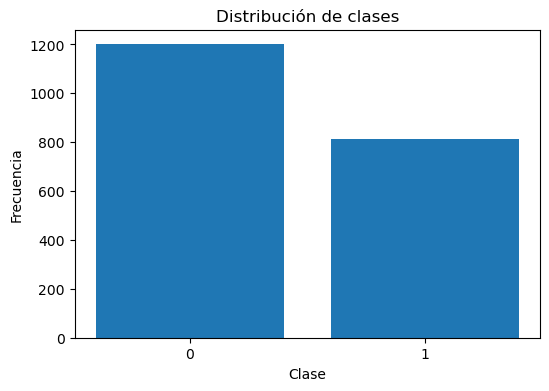


6. Dividiendo datos
X_train: (1508, 0)
X_test: (503, 0)

7. Construyendo preprocesamiento
Preprocesamiento listo.

8. Definiendo modelos candidatos
Modelos definidos: 9

9. Validación cruzada inicial por AUC
Evaluando LogisticRegression...
Error en LogisticRegression: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/home/dnunezf/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dnunezf/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/h

KeyError: 'auc_cv_promedio'

In [19]:
# CELDA 6: Ejecutar todo el proceso inteligente
agent.run_all(DATASET_PATH, top_n_tuning=4)

In [ ]:
# CELDA 7: Ver resultados de validación cruzada
agent.cv_results

In [ ]:
# CELDA 8: Ver resultados optimizados
agent.tuned_results

In [8]:
# CELDA 9: Evaluación final nuevamente
agent.final_evaluation()


12. Evaluación final


AttributeError: 'NoneType' object has no attribute 'predict_proba'

In [9]:
# CELDA 10: Importancia de variables
importance_df = agent.explain_model_with_permutation_importance(n_repeats=10, top_n=20)


13. Importancia de variables
No fue posible calcular importancia de variables: The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got None instead.


In [10]:
# CELDA 11: Predicción con un registro existente
nuevo_registro = agent.X_test.iloc[0].to_dict()
agent.predict_new_data(nuevo_registro)


14. Predicción sobre nuevos datos


AttributeError: 'NoneType' object has no attribute 'predict_proba'

In [11]:
# CELDA 12: Predicción con registro manual
registro_manual = agent.X_test.iloc[0].to_dict()

# Modifique los valores que necesite, por ejemplo:
# registro_manual["ph"] = 7.2
# registro_manual["Hardness"] = 180

agent.predict_new_data(registro_manual)


14. Predicción sobre nuevos datos


AttributeError: 'NoneType' object has no attribute 'predict_proba'

In [12]:
# CELDA 13: Guardar el agente completo
agent.save_agent("smart_auc_agent.pkl")

Agente guardado como: smart_auc_agent.pkl


In [13]:
# CELDA 14: Cargar el agente guardado
loaded_agent = joblib.load("smart_auc_agent.pkl")
loaded_agent.best_model_name, loaded_agent.best_threshold

(None, 0.5)

## Diferencias frente a la versión básica

Esta versión es más inteligente porque toma decisiones automáticas durante el proceso:

- Diagnostica el dataset antes de modelar.
- Elimina duplicados y columnas problemáticas.
- Detecta posibles identificadores.
- Analiza desbalance de clases.
- Usa pesos balanceados cuando corresponde.
- Compara modelos con validación cruzada.
- Optimiza solo los mejores modelos para ahorrar tiempo.
- Busca hiperparámetros automáticamente.
- Ajusta el umbral de clasificación.
- Interpreta el AUC obtenido.
- Calcula importancia de variables.
- Guarda el agente para reutilización.

## Interpretación rápida del AUC

- AUC menor a 0.60: bajo desempeño.
- AUC entre 0.60 y 0.70: desempeño moderado-bajo.
- AUC entre 0.70 y 0.80: aceptable.
- AUC entre 0.80 y 0.90: bueno.
- AUC mayor a 0.90: muy alto; conviene revisar posible fuga de información.